In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv("data/Twitter_Emotion_Dataset.csv")

## EDA

In [45]:
df.head()

,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4401 entries, 0 to 4400
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   4401 non-null   str  
 1   tweet   4401 non-null   str  
dtypes: str(2)
memory usage: 874.8 KB


In [47]:
df.isnull().sum()

label    0
tweet    0
dtype: int64

In [48]:
df['tweet'].duplicated().sum()

np.int64(12)

In [49]:
df = df.drop_duplicates(subset='tweet')

In [50]:
df['label'].unique()

<ArrowStringArray>
['anger', 'happy', 'sadness', 'love', 'fear']
Length: 5, dtype: str

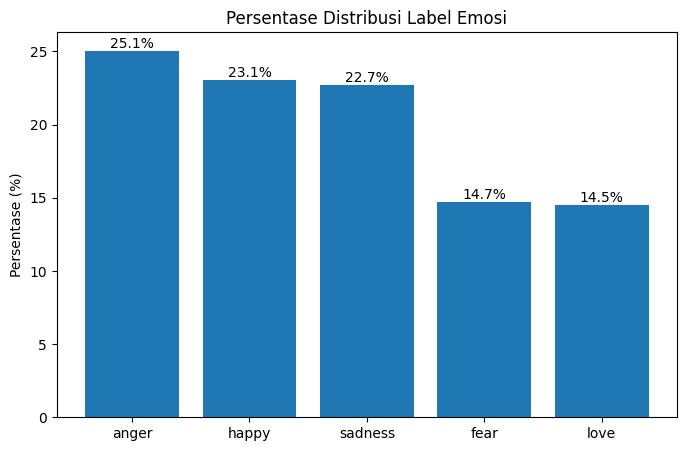

In [51]:
dist = (df['label'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8, 5))
bars = plt.bar(dist.index, dist.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.title('Persentase Distribusi Label Emosi')
plt.ylabel('Persentase (%)')
plt.show()

In [52]:
class_counts = df['label'].value_counts()
print(class_counts)

label
anger      1100
happy      1012
sadness     996
fear        645
love        636
Name: count, dtype: int64


In [53]:
for label in df['label'].unique():
    print(f'LABEL: {label}')

    samples = df[df['label'] == label]['tweet'].sample(
        min(1, len(df[df['label'] == label])),
        random_state=42
    )

    for i, tweet in enumerate(samples, 1):
        print(f'{tweet}\n')

LABEL: anger
Tapi dia itu bule dong, menurut persepsi dia mungkin itu normal, dan gw yakin niatnya tidak untuk melecehkan Pemikiran begini yg bikin orang Indonesia diremehkan bule. Itu orang tipe klo ada bule minta foto pasti  Ingin ku berkata kasar ... KASAR!!!!! [URL]

LABEL: happy
Setelah mandi dilanjutkan dengan makan pagi bagi WBS PSTW BM II Jelambar untuk WBS total care makan pagi dibantu PJLP untuk menambah energi, agar badan tetap segar, sehat dan stamina terjaga.

LABEL: sadness
Harus bisa me-manage waktu lebih baik lagi nih, hrus bner2 memfilter mana yg jdi prioritas. Kan kalo management waktu nya oke hidup bisa #JadiLebihBaik

LABEL: love
Penutup thread ini adalah, saya mohon kamu selalu inget. Saya sayang kamu. Ilysm to the moon and never back, thanks for everything.. Saranghae [USERNAME]

LABEL: fear
[USERNAME] [USERNAME] Deg degan mana sama kalau tbtb mamah bilang "kak tutup taperwer mamah kemana ya? Tadi bukan nya kamu yg abis pakai? " jeng jengggg :(((((((



## Preprocessing

In [54]:
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.StopWordRemover.StopWordRemover import StopWordRemover
import re

### Cleaning

In [55]:
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    text = re.sub(r'rt\s+@\w+:?', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'rt\s+\[username\]:?', '', text)
    text = re.sub(r'\[username\]', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

In [56]:
sample_raw = df['tweet'].iloc[0]
sample_clean = clean_tweet(sample_raw)

print("Sebelum :", sample_raw)
print("Sesudah :", sample_clean)

Sebelum : Soal jln Jatibaru,polisi tdk bs GERTAK gubernur .Emangny polisi tdk ikut pmbhasan? Jgn berpolitik. Pengaturan wilayah,hak gubernur. Persoalan Tn Abang soal turun temurun.Pelik.Perlu kesabaran. [USERNAME] [USERNAME] [URL]
Sesudah : soal jln jatibaru polisi tdk bs gertak gubernur emangny polisi tdk ikut pmbhasan jgn berpolitik pengaturan wilayah hak gubernur persoalan tn abang soal turun temurun pelik perlu kesabaran url


### Normalisasi

In [57]:
df_kamus = pd.read_csv('data/kamus_singkatan.csv', sep=';', header=None, names=['singkatan', 'hasil'])

In [58]:
df_kamus['singkatan'] = df_kamus['singkatan'].astype(str).str.strip()
df_kamus['hasil'] = df_kamus['hasil'].astype(str).str.strip()
kamus_dict = dict(zip(df_kamus['singkatan'], df_kamus['hasil']))

In [59]:
def normalize(text):
    kata_kata = text.split()
    kata_normal = [kamus_dict.get(kata, kata) for kata in kata_kata]
    return ' '.join(kata_normal)

In [60]:
df['normal_tweet'] = df['clean_tweet'].apply(normalize)

In [61]:
sample_raw = df['clean_tweet'].iloc[0]
sample_clean = normalize(sample_raw)

print("Sebelum :", sample_raw)
print("Sesudah :", sample_clean)

Sebelum : soal jln jatibaru polisi tdk bs gertak gubernur emangny polisi tdk ikut pmbhasan jgn berpolitik pengaturan wilayah hak gubernur persoalan tn abang soal turun temurun pelik perlu kesabaran url
Sesudah : soal jalan jatibaru polisi tidak bisa gertak gubernur emangny polisi tidak ikut pmbhasan jangan berpolitik pengaturan wilayah hak gubernur persoalan tn abang soal turun temurun pelik perlu kesabaran url


In [62]:
df.head()

,label,tweet,clean_tweet,normal_tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",soal jln jatibaru polisi tdk bs gertak gubernu...,soal jalan jatibaru polisi tidak bisa gertak g...
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",sesama cewe lho kayaknya harusnya bisa lebih r...,sesama cewek lho kayaknya harusnya bisa lebih ...
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj amad foto dari goo...,kepingin gudeg mbarek bu hj amad foto dari goo...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",jln jatibaru bagian dari wilayah tn abang peng...,jalan jatibaru bagian dari wilayah tn abang pe...
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman aja kemarin jam batalin tik...,sharing pengalaman saja kemarin jam batalin ti...


### Stopword

In [63]:
extra_stopwords = [
    'kamu', 'saya', 'aku', 'ku', 'mu', 'nya', 'kami', 'kita', 'dia', 'mereka',
    'yang', 'dan', 'di', 'ke', 'dari', 'dengan', 'untuk', 'atau', 'tapi',
    'karena', 'kalau', 'jika', 'agar', 'supaya', 'namun', 'tetapi', 'serta',
    'tidak', 'tak', 'bukan', 'mau', 'bisa', 'ada', 'sudah', 'belum',
    'akan', 'jadi', 'terus', 'sama', 'aja', 'juga', 'udah', 'sih', 'deh',
    'dong', 'loh', 'lah', 'kan', 'pun', 'tuh', 'nih',
    'lebih', 'sekali', 'sangat', 'banyak', 'semua', 'setiap', 'para',
    'hari', 'ini', 'itu', 'sini', 'sana', 'situ', 'sekarang', 'nanti',
    'url', 'pas', 'buat', 'pakai', 'tahu', 'memang', 'orang', 'apa',
    'sudah', 'sendiri', 'salah', 'bisa', 'baru', 'cuma', 'teman'
]

factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()
all_stopwords = set(sastrawi_stopwords + extra_stopwords)
def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in all_stopwords])

df['final_tweet'] = df['normal_tweet'].apply(remove_stopwords)

In [64]:
df.head()

,label,tweet,clean_tweet,normal_tweet,final_tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",soal jln jatibaru polisi tdk bs gertak gubernu...,soal jalan jatibaru polisi tidak bisa gertak g...,soal jalan jatibaru polisi gertak gubernur ema...
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",sesama cewe lho kayaknya harusnya bisa lebih r...,sesama cewek lho kayaknya harusnya bisa lebih ...,sesama cewek lho kayaknya harusnya rasain sibu...
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj amad foto dari goo...,kepingin gudeg mbarek bu hj amad foto dari goo...,kepingin gudeg mbarek bu hj amad foto google s...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",jln jatibaru bagian dari wilayah tn abang peng...,jalan jatibaru bagian dari wilayah tn abang pe...,jalan jatibaru bagian wilayah tn abang pengatu...
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman aja kemarin jam batalin tik...,sharing pengalaman saja kemarin jam batalin ti...,sharing pengalaman kemarin jam batalin tiket s...


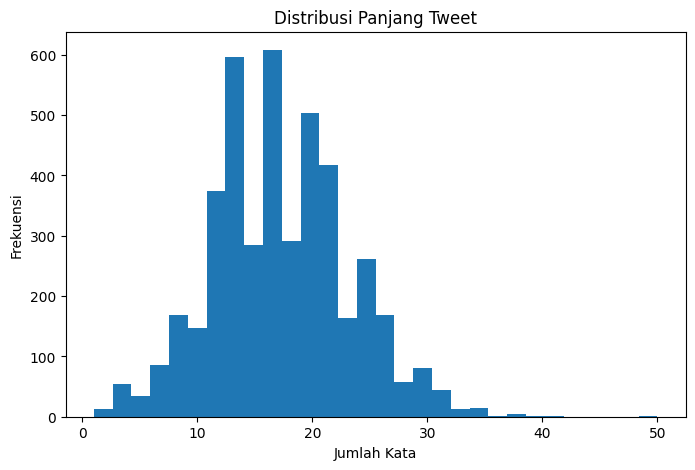

In [65]:
df['final_word_count'] = df['final_tweet'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
plt.hist(df['final_word_count'], bins=30)
plt.title('Distribusi Panjang Tweet')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

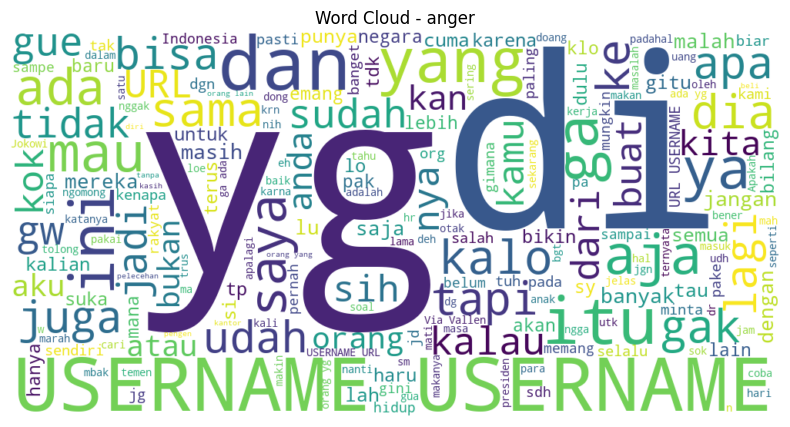

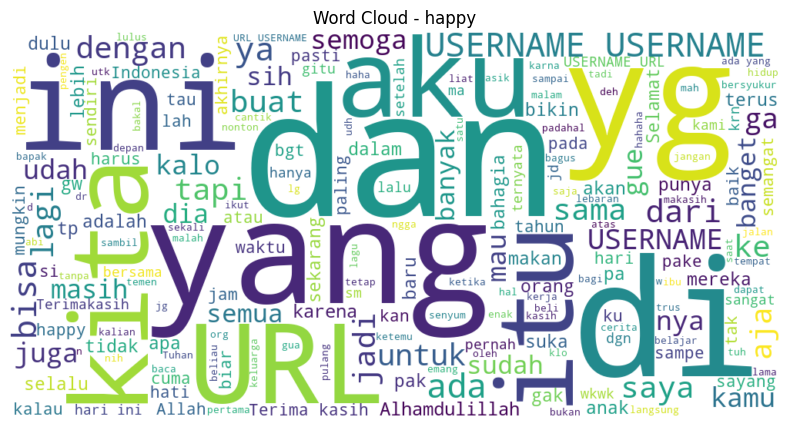

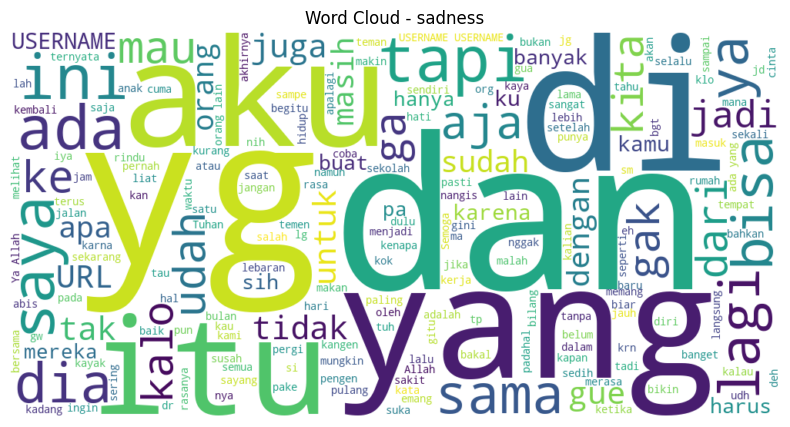

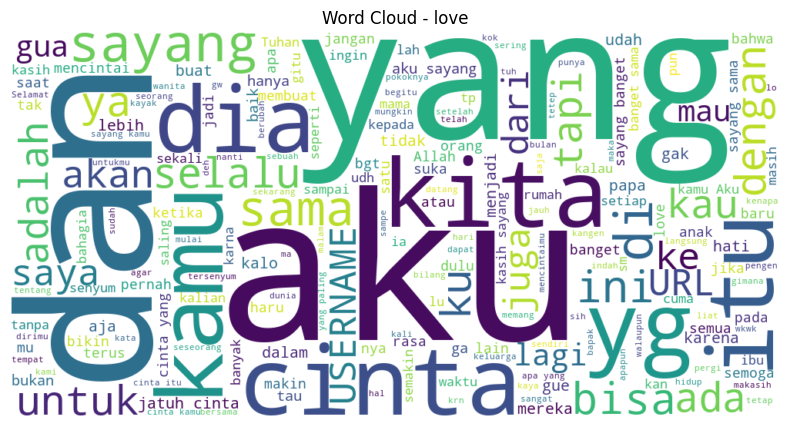

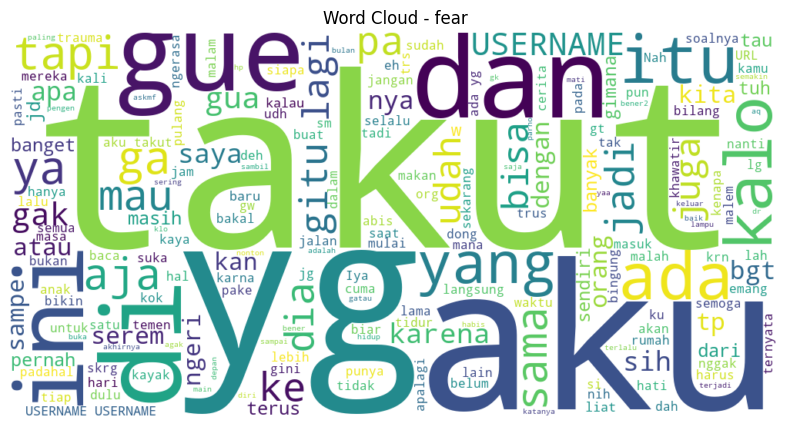

In [66]:
for emotion in df['label'].unique():

    text = " ".join(
        df[df['label'] == emotion]['tweet']
        .astype(str)
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {emotion}')
    plt.show()

In [69]:
df.head()

,label,tweet,clean_tweet,normal_tweet,final_tweet,final_word_count
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",soal jln jatibaru polisi tdk bs gertak gubernu...,soal jalan jatibaru polisi tidak bisa gertak g...,soal jalan jatibaru polisi gertak gubernur ema...,25
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",sesama cewe lho kayaknya harusnya bisa lebih r...,sesama cewek lho kayaknya harusnya bisa lebih ...,sesama cewek lho kayaknya harusnya rasain sibu...,25
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj amad foto dari goo...,kepingin gudeg mbarek bu hj amad foto dari goo...,kepingin gudeg mbarek bu hj amad foto google s...,13
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",jln jatibaru bagian dari wilayah tn abang peng...,jalan jatibaru bagian dari wilayah tn abang pe...,jalan jatibaru bagian wilayah tn abang pengatu...,31
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman aja kemarin jam batalin tik...,sharing pengalaman saja kemarin jam batalin ti...,sharing pengalaman kemarin jam batalin tiket s...,22


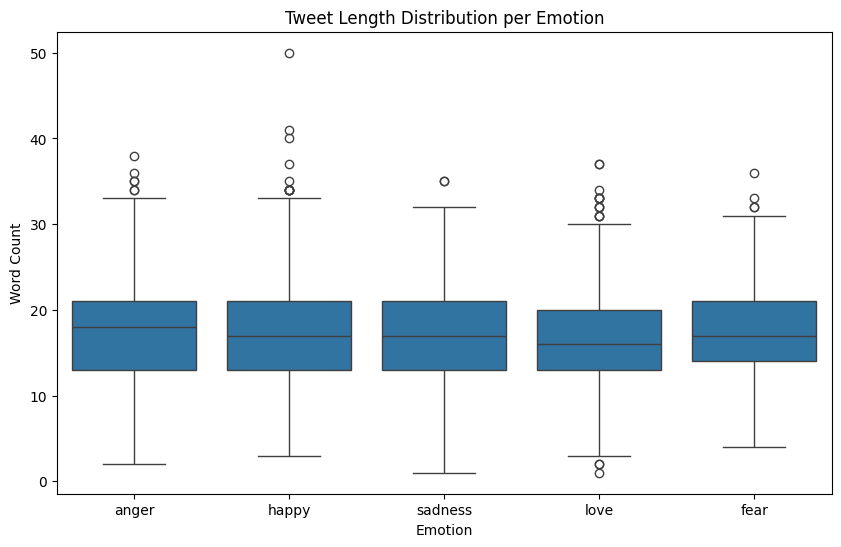

In [70]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='label',
    y='final_word_count'
)

plt.title('Tweet Length Distribution per Emotion')
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.show()

## Embedding

In [71]:
from sentence_transformers import SentenceTransformer
import umap

In [72]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [73]:
sentences = df['final_tweet'].tolist()
embeddings = model.encode(sentences, batch_size=64, show_progress_bar=True)

np.save('artifacts/embeddings.npy', embeddings)
print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/69 [00:00<?, ?it/s]

Embeddings shape: (4389, 384)


In [74]:
embeddings = np.load('artifacts/embeddings.npy')

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

print("2D shape:", embeddings_2d.shape)

e:\Naad\Projects\nolimit-ds-test-nadafirdaus\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D shape: (4389, 2)


## Clustering

In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import faiss
from sklearn.feature_extraction.text import TfidfVectorizer

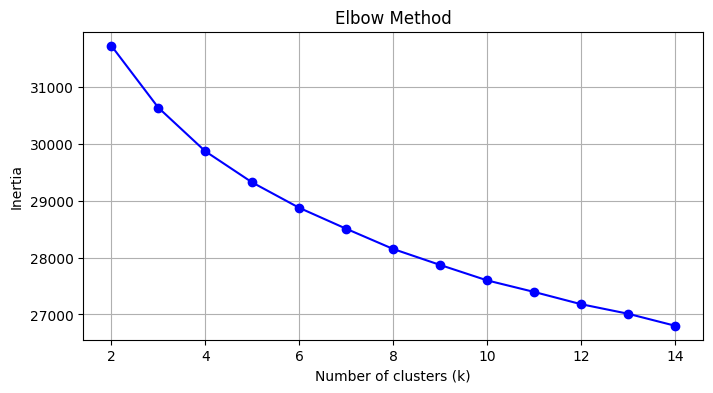

In [76]:
inertias = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(embeddings)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

In [77]:
for k in [5, 6, 7]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels, sample_size=1000, random_state=42)
    print(f"k={k} | Silhouette Score: {score:.4f}")

k=5 | Silhouette Score: 0.0391
k=6 | Silhouette Score: 0.0399
k=7 | Silhouette Score: 0.0297


In [78]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(embeddings)

embeddings_f32 = embeddings.astype('float32')
index = faiss.IndexFlatL2(embeddings_f32.shape[1])
index.add(embeddings_f32)

print("FAISS index total vectors:", index.ntotal)
print("Cluster distribution:")
print(df['cluster'].value_counts().sort_index())

FAISS index total vectors: 4389
Cluster distribution:
cluster
0     907
1     570
2     764
3    1329
4     819
Name: count, dtype: int64


In [79]:
df['final_tweet'].head()

0    soal jalan jatibaru polisi gertak gubernur ema...
1    sesama cewek lho kayaknya harusnya rasain sibu...
2    kepingin gudeg mbarek bu hj amad foto google s...
3    jalan jatibaru bagian wilayah tn abang pengatu...
4    sharing pengalaman kemarin jam batalin tiket s...
Name: final_tweet, dtype: str

In [80]:
cluster_labels = {}

for i in range(5):
    cluster_tweets = df[df['cluster'] == i]['final_tweet'].tolist()
    
    vectorizer = TfidfVectorizer(max_features=10, min_df=2)
    vectorizer.fit(cluster_tweets)
    
    tfidf_matrix = vectorizer.transform(cluster_tweets)
    mean_scores = tfidf_matrix.mean(axis=0).A1
    top_indices = mean_scores.argsort()[::-1][:10]
    top_keywords = [vectorizer.get_feature_names_out()[j] for j in top_indices]
    
    cluster_labels[i] = top_keywords
    print(f"\nCluster {i} ({len(cluster_tweets)} tweets):")
    print("Top keywords:", top_keywords)


Cluster 0 (907 tweets):
Top keywords: ['jangan', 'benar', 'malah', 'dulu', 'punya', 'kok', 'kerja', 'selalu', 'negara', 'pak']

Cluster 1 (570 tweets):
Top keywords: ['cinta', 'sayang', 'selalu', 'kasih', 'hati', 'pernah', 'jatuh', 'jangan', 'baik', 'allah']

Cluster 2 (764 tweets):
Top keywords: ['semoga', 'sayang', 'cinta', 'indonesia', 'suka', 'selamat', 'kasih', 'allah', 'happy', 'selalu']

Cluster 3 (1329 tweets):
Top keywords: ['takut', 'sayang', 'suka', 'bikin', 'dulu', 'jangan', 'anak', 'malam', 'makan', 'si']

Cluster 4 (819 tweets):
Top keywords: ['takut', 'pernah', 'selalu', 'punya', 'malah', 'suka', 'benar', 'jangan', 'diri', 'hati']


In [81]:
cluster_topic_map = {
    0: 'Politik & Sosial',
    1: 'Cinta & Romansa',
    2: 'Doa & Harapan',
    3: 'Kehidupan Sehari-hari',
    4: 'Kegelisahan & Refleksi'
}

df['topic'] = df['cluster'].map(cluster_topic_map)
df['topic'].value_counts()

topic
Kehidupan Sehari-hari     1329
Politik & Sosial           907
Kegelisahan & Refleksi     819
Doa & Harapan              764
Cinta & Romansa            570
Name: count, dtype: int64

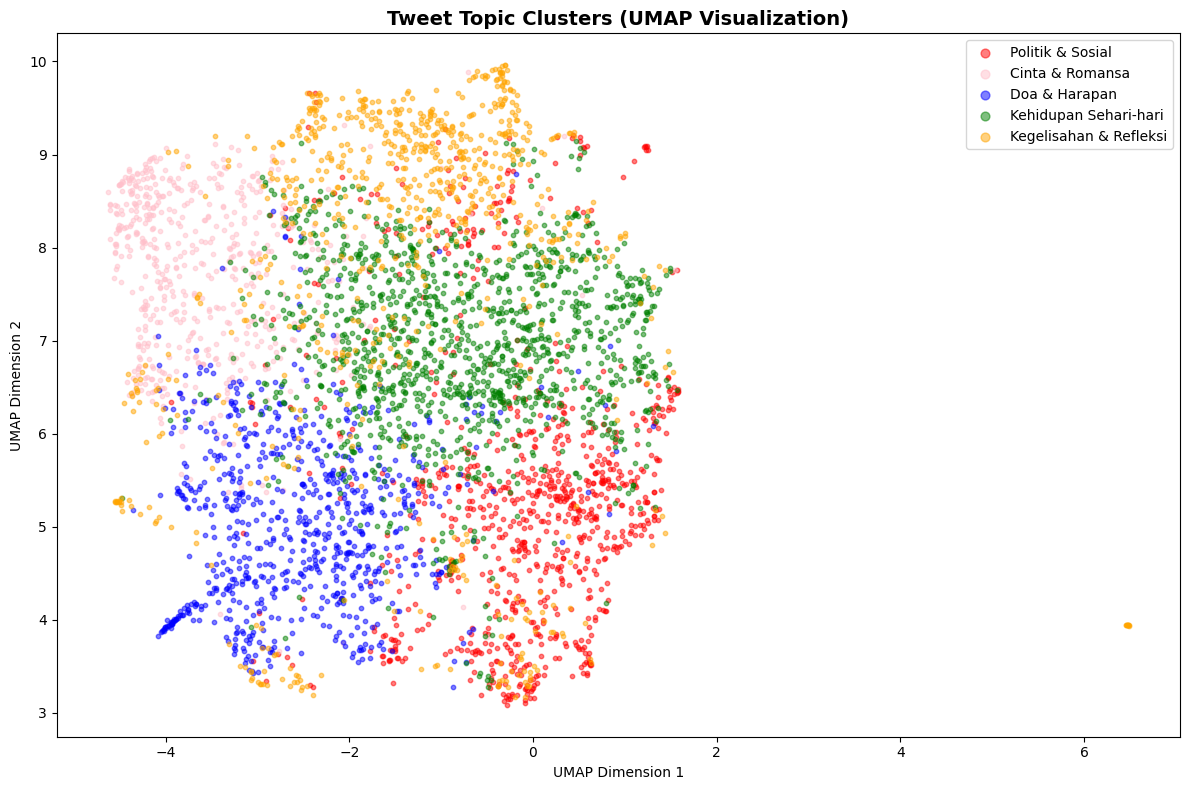

In [ ]:
topic_colors = {
    'Politik & Sosial'      : 'red',
    'Cinta & Romansa'       : 'pink',
    'Doa & Harapan'         : 'blue',
    'Kehidupan Sehari-hari' : 'green',
    'Kegelisahan & Refleksi': 'orange'
}

plt.figure(figsize=(12, 8))

for topic, color in topic_colors.items():
    mask = df['topic'] == topic
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=color,
        label=topic,
        alpha=0.5,
        s=10
    )

plt.title('Tweet Topic Clusters (UMAP Visualization)', fontsize=14, fontweight='bold')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(loc='upper right', markerscale=2)
plt.tight_layout()
plt.show()

## Classification

In [83]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
import accelerate
import transformers
from sklearn.utils.class_weight import compute_class_weight
import torch
from sklearn.metrics import accuracy_score, f1_score

In [84]:
label2id = {'anger': 0, 'fear': 1, 'happy': 2, 'love': 3, 'sadness': 4}
id2label = {v: k for k, v in label2id.items()}
df['label'] = df['label'].map(label2id)

In [86]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
test_df, val_df  = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['label'])
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 3511 | Val: 439 | Test: 439


In [87]:
class EmoDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

In [88]:
MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [89]:
train_dataset = EmoDataset(train_df['normal_tweet'], train_df['label'], tokenizer)
val_dataset   = EmoDataset(val_df['normal_tweet'],   val_df['label'],   tokenizer)
test_dataset  = EmoDataset(test_df['normal_tweet'],  test_df['label'],  tokenizer)

In [93]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1_macro': f1}

In [94]:
training_args = TrainingArguments(
    output_dir='artifacts/model_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir='artifacts/logs',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [96]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
weights_tensor = torch.tensor(list(class_weights), dtype=torch.float)
weights_tensor

tensor([0.7980, 1.3609, 0.8680, 1.3796, 0.8811])

In [97]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=weights_tensor.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [98]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
e:\Naad\Projects\nolimit-ds-test-nadafirdaus\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.786021,0.802462,0.683371,0.689458
2,0.552413,0.742490,0.722096,0.726935
3,0.249294,0.845190,0.735763,0.739980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

e:\Naad\Projects\nolimit-ds-test-nadafirdaus\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

e:\Naad\Projects\nolimit-ds-test-nadafirdaus\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=660, training_loss=0.6078052148674473, metrics={'train_runtime': 6666.9005, 'train_samples_per_second': 1.58, 'train_steps_per_second': 0.099, 'total_flos': 346427924321664.0, 'train_loss': 0.6078052148674473, 'epoch': 3.0})

## Evaluation

In [99]:
from sklearn.metrics import classification_report, confusion_matrix

In [100]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

e:\Naad\Projects\nolimit-ds-test-nadafirdaus\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [101]:
id2label = {0: 'anger', 1: 'fear', 2: 'happy', 3: 'love', 4: 'sadness'}
print(classification_report(true_labels, preds, target_names=list(id2label.values())))

              precision    recall  f1-score   support

       anger       0.70      0.74      0.72       110
        fear       0.67      0.75      0.71        64
       happy       0.83      0.70      0.76       102
        love       0.79      0.84      0.82        63
     sadness       0.61      0.60      0.61       100

    accuracy                           0.71       439
   macro avg       0.72      0.72      0.72       439
weighted avg       0.72      0.71      0.71       439



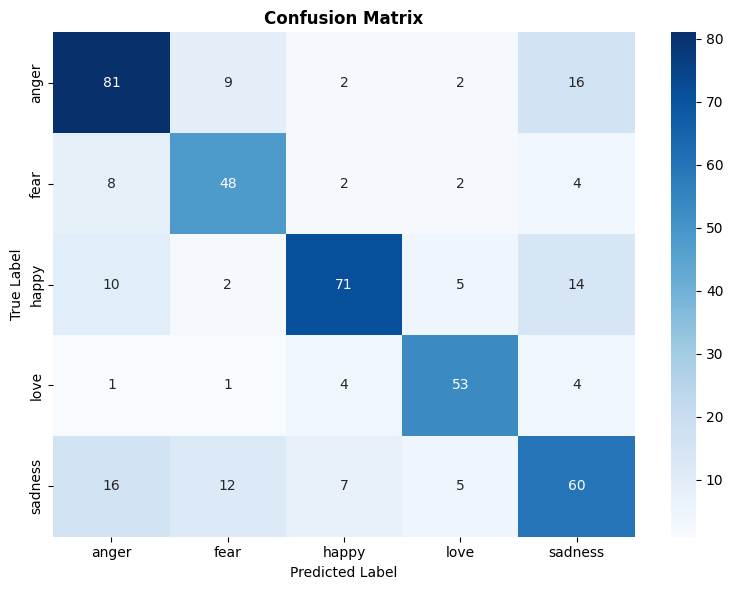

In [ ]:
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(id2label.values()),
            yticklabels=list(id2label.values()))
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [103]:
trainer.save_model('artifacts/model_output/best_model')
tokenizer.save_pretrained('artifacts/model_output/best_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('artifacts/model_output/best_model\\tokenizer_config.json',
 'artifacts/model_output/best_model\\tokenizer.json')

In [4]:
from huggingface_hub import HfApi

api = HfApi()
api.create_repo(repo_id="Nadaa9/indobert-emotion-twitter", private=False)

RepoUrl('https://huggingface.co/Nadaa9/indobert-emotion-twitter', endpoint='https://huggingface.co', repo_type='model', repo_id='Nadaa9/indobert-emotion-twitter')

In [6]:
model.push_to_hub("Nadaa9/indobert-emotion-twitter")
tokenizer.push_to_hub("Nadaa9/indobert-emotion-twitter")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

e:\Naad\Projects\nolimit-ds-test-nadafirdaus\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--Nadaa9--indobert-emotion-twitter. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


CommitInfo(commit_url='https://huggingface.co/Nadaa9/indobert-emotion-twitter/commit/ab01e59da3516e101a92a1365e9af71f3bde5202', commit_message='Upload tokenizer', commit_description='', oid='ab01e59da3516e101a92a1365e9af71f3bde5202', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Nadaa9/indobert-emotion-twitter', endpoint='https://huggingface.co', repo_type='model', repo_id='Nadaa9/indobert-emotion-twitter'), pr_revision=None, pr_num=None)

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("Nadaa9/indobert-emotion-twitter")
model = AutoModelForSequenceClassification.from_pretrained("Nadaa9/indobert-emotion-twitter")
model.eval()

print("Labels:", model.config.id2label)

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

e:\Naad\Projects\nolimit-ds-test-nadafirdaus\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--Nadaa9--indobert-emotion-twitter. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/709k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!
Labels: {0: 'anger', 1: 'fear', 2: 'happy', 3: 'love', 4: 'sadness'}


In [3]:
api.upload_file(
    path_or_fileobj="artifacts/embeddings.npy",
    path_in_repo="embeddings.npy",
    repo_id="Nadaa9/indobert-emotion-twitter",
    repo_type="model"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Nadaa9/indobert-emotion-twitter/commit/be8290e5ad72ab855e0000577f55e6d9896f6b6a', commit_message='Upload embeddings.npy with huggingface_hub', commit_description='', oid='be8290e5ad72ab855e0000577f55e6d9896f6b6a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Nadaa9/indobert-emotion-twitter', endpoint='https://huggingface.co', repo_type='model', repo_id='Nadaa9/indobert-emotion-twitter'), pr_revision=None, pr_num=None)

In [104]:
df_test = test_df.copy()
df_test['predicted_emotion'] = [id2label[p] for p in preds]
df_test['true_emotion'] = [id2label[t] for t in true_labels]
df_test['topic'] = df_test.index.map(df['topic'])

In [105]:
sample = df_test[['tweet', 'topic', 'predicted_emotion', 'true_emotion']].sample(10, random_state=42)
print(sample.to_string(index=False))

                                                                                                                                                                                                                                                               tweet                  topic predicted_emotion true_emotion
                                                                                  Semoga sehat selalu, dan yg terpenting selalu sayang dan cinta ama [USERNAME], walaupun gw itu followers baru tp kita bisa saling kenal krn kita keluarga we are family I love you          Doa & Harapan              love         love
                                                                              Belajarlah ONTIME mister olala. Ckp sdh setahun trs2 an telat. Rmh dkt. Ditegor kitudeui2... Jubras jebris.. Punyan panyun.. Batur mah 3X salah lsg SP 3... krg sabar kumaha deui aku.  Kehidupan Sehari-hari             anger        anger
                                                       

In [106]:
df_test[['tweet', 'topic', 'predicted_emotion', 'true_emotion']].to_csv(
    'artifacts/predictions.csv', index=False
)

In [107]:
crosstab = pd.crosstab(df_test['topic'], df_test['predicted_emotion'])
print("\nEmotion distribution per topic:")
print(crosstab)


Emotion distribution per topic:
predicted_emotion       anger  fear  happy  love  sadness
topic                                                    
Cinta & Romansa             2     0     11    32        8
Doa & Harapan              17     4     35    14       11
Kegelisahan & Refleksi     28    31      4     5       26
Kehidupan Sehari-hari      22    28     20    16       35
Politik & Sosial           47     9     16     0       18


In [108]:
sample_output = df_test[['tweet', 'topic', 'predicted_emotion', 'true_emotion']].sample(20, random_state=42)
sample_output.to_csv('data/sample.csv', index=False)